# Layer10 Take-Home
**Corpus:** `psf/requests` GitHub issues and comments

Fetched real GitHub issues, entities and facts from there and store everything with proof, finally make it searchable via a UI.

In [1]:
!pip install requests networkx groq tqdm pyngrok streamlit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 54.5 MB/s eta 0:00:00


## Setup
need to put own API keys here before running anything.

groq api key - can get it free from "https://console.groq.com/keys", if not logged in just log in and generate a new key copy paste that here.

github token - again log into github, from "https://github.com/settings/tokens", generate a new key and copy paste it here.

later towards the end ngrok auth token also required.

In [2]:
import os, json, uuid, re
from datetime import datetime

# add keys here
GROQ_API_KEY   = os.environ.get("GROQ_API_KEY",   "YOURKEYHERE")   # free at console.groq.com
GITHUB_TOKEN   = os.environ.get("GITHUB_TOKEN",   "YOURKEYHERE") # free at github.com/settings/tokens

OWNER          = "psf"
REPO           = "requests"
TARGET_ISSUES  = 40
SCHEMA_VERSION = "v1.0"
MODEL          = "llama-3.1-8b-instant"
print("Config ok")


Config ok


## 1. Fetch the data
Data fetched by pulling 40 real issues (and their comments) from the `psf/requests` repo on GitHub. This is the raw corpus from this we extract memory from.

In [3]:
import requests as http_lib
from tqdm import tqdm

HEADERS = {"Authorization": f"token {GITHUB_TOKEN}"}

def fetch_real_issues(owner, repo, target_count=40):
    all_issues, page = [], 1
    while len(all_issues) < target_count:
        r = http_lib.get(
            f"https://api.github.com/repos/{owner}/{repo}/issues",
            params={"state": "all", "per_page": 30, "page": page},
            headers=HEADERS
        )
        if r.status_code != 200:
            print("GitHub API error:", r.status_code); break
        batch = r.json()
        if not batch: break
        all_issues.extend(i for i in batch if "pull_request" not in i)
        page += 1
    return all_issues[:target_count]

def fetch_comments(owner, repo, issue_number):
    r = http_lib.get(
        f"https://api.github.com/repos/{owner}/{repo}/issues/{issue_number}/comments",
        headers=HEADERS
    )
    if r.status_code != 200: return []
    return r.json()

raw_issues = fetch_real_issues(OWNER, REPO, TARGET_ISSUES)
print(f"Fetched {len(raw_issues)} issues")

Fetched 40 issues


In [4]:
def normalize_issue(issue):
    return {
        "issue_id"  : issue["number"],
        "title"     : issue["title"],
        "body"      : (issue["body"] or "").strip(),
        "state"     : issue["state"],
        "created_at": issue["created_at"],
        "closed_at" : issue["closed_at"],
        "author"    : issue["user"]["login"] if issue["user"] else None,
        "assignees" : [a["login"] for a in issue["assignees"]],
        "labels"    : [l["name"]  for l in  issue["labels"]],
        "url"       : issue["html_url"],
    }

def normalize_comment(c, issue_id):
    return {
        "comment_id": c["id"],
        "issue_id"  : issue_id,
        "author"    : c["user"]["login"] if c["user"] else None,
        "body"      : (c["body"] or "").strip(),
        "created_at": c["created_at"],
        "url"       : c["html_url"],
    }

clean_issues = [normalize_issue(i) for i in raw_issues]

all_comments = []
for issue in tqdm(clean_issues, desc="Fetching comments"):
    raw_c = fetch_comments(OWNER, REPO, issue["issue_id"])
    all_comments.extend(normalize_comment(c, issue["issue_id"]) for c in raw_c)

print(f"Issues: {len(clean_issues)}  |  Comments: {len(all_comments)}")


Fetching comments: 100%|██████████| 40/40 [00:16<00:00,  2.46it/s]

Issues: 40  |  Comments: 47


## 2. Store artifacts and remove duplicates
Before anything else we should check if two messages are basically the same thing (like if someone copy-pasted a comment). So a content hash for exact matches and word overlap for near matches are used.

Duplicates are flagged but kept where they were so we can always trace back where they came from.

In [5]:
import hashlib
from difflib import SequenceMatcher

def text_hash(text):
    return hashlib.sha256(text.encode()).hexdigest()

def jaccard_similarity(a, b):
    sa, sb = set(a.lower().split()), set(b.lower().split())
    if not sa or not sb: return 0.0
    return len(sa & sb) / len(sa | sb)

# artifact store: artifact_id - artifact dict
artifact_store   = {}
hash_index       = {}   # hash - artifact_id  (exact dedup)
content_index    = []   # list of (artifact_id, text) for fuzzy dedup

def add_artifact(artifact_id, artifact_type, issue_id, author, text, created_at, url):
    h = text_hash(text)
    # 1. exact dedup
    if h in hash_index:
        artifact_store[artifact_id] = {**artifact_store[hash_index[h]],
            "artifact_id": artifact_id, "is_duplicate": True,
            "duplicate_of": hash_index[h]}
        return artifact_id

    # near-duplicate (Jaccard > 0.85 for non-trivial texts)
    if len(text.split()) > 10:
        for cid, ctext in content_index:
            if jaccard_similarity(text, ctext) > 0.85:
                artifact_store[artifact_id] = {
                    "artifact_id": artifact_id, "artifact_type": artifact_type,
                    "issue_id": issue_id, "author": author, "text": text,
                    "created_at": created_at, "url": url, "hash": h,
                    "is_duplicate": True, "duplicate_of": cid}
                return artifact_id

    # canonical
    obj = {"artifact_id": artifact_id, "artifact_type": artifact_type,
           "issue_id": issue_id, "author": author, "text": text,
           "created_at": created_at, "url": url, "hash": h,
           "is_duplicate": False, "duplicate_of": None}
    artifact_store[artifact_id] = obj
    hash_index[h] = artifact_id
    content_index.append((artifact_id, text))
    return artifact_id

for issue in clean_issues:
    add_artifact(f"issue_{issue['issue_id']}_body", "issue_body",
                 issue["issue_id"], issue["author"], issue["body"],
                 issue["created_at"], issue["url"])

for c in all_comments:
    add_artifact(f"comment_{c['comment_id']}", "comment",
                 c["issue_id"], c["author"], c["body"],
                 c["created_at"], c["url"])

dupes = sum(1 for a in artifact_store.values() if a["is_duplicate"])
print(f"Artifacts: {len(artifact_store)}  |  Duplicates detected: {dupes}")


Artifacts: 87  |  Duplicates detected: 16


## 3. Building memory graph
graph stores three things:
- **Entities** - the people, issues, labels, states, and concepts we find
- **Claims** - facts connecting two entities like 'user X created issue Y'
- **Evidence** - the exact text snippet that proves each claim with a link back to the source

also every claim has a `valid_from` and `valid_to` date so we can track when something was true vs when it changed (example, issue going from open to closed).

In [6]:
# in memory graph store
entities  = {}          # entity_id  - entity dict
claims    = {}          # claim_id   - claim dict
evidences = {}          # evidence_id - evidence dict

entity_index = {}       # (type, canonical_name.lower()) - entity_id  [dedup]
claim_index  = {}       # (subject_id, relation, object_id) - claim_id [dedup]

def get_or_create_entity(entity_type, canonical_name, aliases=None):
    key = (entity_type, canonical_name.lower())
    if key in entity_index:
        return entity_index[key]
    eid = str(uuid.uuid4())
    entities[eid] = {
        "entity_id"      : eid,
        "entity_type"    : entity_type,
        "canonical_name" : canonical_name,
        "aliases"        : list(set([canonical_name] + (aliases or []))),
    }
    entity_index[key] = eid
    return eid

def create_evidence(artifact, excerpt, offset_start=None):
    eid = str(uuid.uuid4())
    evidences[eid] = {
        "evidence_id"  : eid,
        "artifact_id"  : artifact["artifact_id"],
        "excerpt"      : excerpt[:500],
        "offset_start" : offset_start or (artifact["text"].find(excerpt) if excerpt in artifact["text"] else -1),
        "timestamp"    : artifact["created_at"],
        "url"          : artifact["url"],
    }
    return eid

def get_or_create_claim(subject_id, relation, object_id, event_time,
                        evidence_id, confidence=1.0, version=None):
    key = (subject_id, relation, object_id)
    if key in claim_index:
        cid = claim_index[key]
        if evidence_id not in claims[cid]["evidence_ids"]:
            claims[cid]["evidence_ids"].append(evidence_id)
            # more evidence means higher confidence
            claims[cid]["confidence"] = min(1.0, claims[cid]["confidence"] + 0.05)
        return cid
    cid = str(uuid.uuid4())
    claims[cid] = {
        "claim_id"          : cid,
        "subject"           : subject_id,
        "relation"          : relation,
        "object"            : object_id,
        "event_time"        : event_time,
        "valid_from"        : event_time,
        "valid_to"          : None,           # none = still current
        "confidence"        : confidence,
        "extraction_version": version or f"{SCHEMA_VERSION}|structured",
        "evidence_ids"      : [evidence_id],
    }
    claim_index[key] = cid
    return cid

def close_claim(claim_id, valid_to_time):
    """Mark a claim as no longer current (e.g. issue re-opened, assignee changed)."""
    claims[claim_id]["valid_to"] = valid_to_time

print("Memory graph structures ready.")


Memory graph structures ready.


## 4a. Extract facts - rule-based pass

Since problem statement involves using 2-phase extraction, this is the first phase which doesnt use LLM so it is faster as well.
Directly read the GitHub data to create facts like who created which issue, what state its in, who is assigned, what labels it has. These are all 100% reliable so confidence = 1.

In [7]:
def get_artifact(artifact_id):
    return artifact_store.get(artifact_id)

def ingest_structured():
    for issue in clean_issues:
        art_id  = f"issue_{issue['issue_id']}_body"
        artifact = get_artifact(art_id)
        if not artifact: continue

        issue_eid = get_or_create_entity("Issue", f"#{issue['issue_id']}: {issue['title'][:60]}")

        # "created by"
        if issue["author"]:
            author_eid = get_or_create_entity("Person", issue["author"])
            ev = create_evidence(artifact, issue["title"])
            get_or_create_claim(issue_eid, "CREATED_BY", author_eid, issue["created_at"], ev)

        # "has state" (with valid_to when closed)
        state_eid = get_or_create_entity("State", issue["state"])
        ev = create_evidence(artifact, f"state={issue['state']}")
        cid = get_or_create_claim(issue_eid, "HAS_STATE", state_eid, issue["created_at"], ev)
        if issue["state"] == "closed" and issue["closed_at"]:
            # also added an open claim that was then closed
            open_eid = get_or_create_entity("State", "open")
            ev2 = create_evidence(artifact, "state=open (at creation)")
            cid2 = get_or_create_claim(issue_eid, "HAS_STATE", open_eid, issue["created_at"], ev2)
            close_claim(cid2, issue["closed_at"])

        #"assigned to"
        for assignee in issue["assignees"]:
            a_eid = get_or_create_entity("Person", assignee)
            ev = create_evidence(artifact, f"assignee={assignee}")
            get_or_create_claim(issue_eid, "ASSIGNED_TO", a_eid, issue["created_at"], ev)

        #"has label"
        for label in issue["labels"]:
            l_eid = get_or_create_entity("Label", label)
            ev = create_evidence(artifact, f"label={label}")
            get_or_create_claim(issue_eid, "HAS_LABEL", l_eid, issue["created_at"], ev)

    #"commented on"
    for c in all_comments:
        art_id   = f"comment_{c['comment_id']}"
        artifact = get_artifact(art_id)
        if not artifact or artifact["is_duplicate"]: continue
        if not c["author"]: continue

        issue_eid     = get_or_create_entity("Issue", next(
            (f"#{i['issue_id']}: {i['title'][:60]}" for i in clean_issues if i["issue_id"]==c["issue_id"]),
            f"#{c['issue_id']}: (unknown)"))
        commenter_eid = get_or_create_entity("Person", c["author"])
        ev = create_evidence(artifact, c["body"][:200])
        get_or_create_claim(commenter_eid, "COMMENTED_ON", issue_eid, c["created_at"], ev)

ingest_structured()
print(f"After structured pass — Entities: {len(entities)}  Claims: {len(claims)}  Evidence: {len(evidences)}")

After structured pass — Entities: 85  Claims: 158  Evidence: 165


## 4b. Extract facts - LLM pass
Second pass will send each message to the Groq LLM to pull out deeper facts from the actual text things like what problem is being reported, what solution someone is proposing, or which other issues are mentioned.

The LLM output is validated — bad JSON gets repaired and weak extractions below confidence 0.5 are thrown.

In [8]:
from groq import Groq
import time

groq_client = Groq(api_key=GROQ_API_KEY)

VALID_RELATIONS = {
    "MENTIONS_USER", "REFERENCES_ISSUE",
    "PROPOSES_SOLUTION", "REPORTS_PROBLEM"
}

EXTRACTION_PROMPT = EXTRACTION_PROMPT = """You are an information extraction system for a software issue tracker.
Extract factual claims from the text below.

Return ONLY a valid JSON array (no markdown, no preamble). Schema:
[{{"relation": "MENTIONS_USER|REFERENCES_ISSUE|PROPOSES_SOLUTION|REPORTS_PROBLEM",
   "object": "<short noun phrase>",
   "excerpt": "<verbatim snippet from text, ≤120 chars>",
   "confidence": <float>}}]

Confidence means: how clearly is this claim supported by the text?
- If the text explicitly and directly states it then confidence would be 1.0
- If you had to read between the lines or infer it then lower the confidence accordingly would be less than 1.0 you should figure out that number based on how much you had to read into
- If it is ambiguous or you are not sure → around 0.5

Rules:
- Only include claims clearly supported by the text
- Excerpt MUST be a substring of the text
- If nothing useful, return []

Text:
{text}"""

def extract_claims_llm(text, retries=2):
    prompt = EXTRACTION_PROMPT.format(text=text[:1500])
    for attempt in range(retries + 1):
        try:
            resp = groq_client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=512,
            )
            raw = resp.choices[0].message.content.strip()
            # repair: strip markdown fences if present
            raw = re.sub(r"^```[a-z]*\n?|```$", "", raw, flags=re.M).strip()
            data = json.loads(raw)
            if not isinstance(data, list): return []
            # validate each claim
            valid = []
            for c in data:
                if not all(k in c for k in ("relation","object","excerpt","confidence")):
                    continue
                if c["relation"] not in VALID_RELATIONS: continue
                if float(c.get("confidence", 0)) < 0.5: continue
                valid.append(c)
            return valid
        except json.JSONDecodeError:
            # try to find array in output
            m = re.search(r"\[.*\]", raw, re.DOTALL)
            if m:
                try: return json.loads(m.group())
                except: pass
        except Exception as e:
            if attempt < retries:
                time.sleep(1)
    return []

print("LLM extractor ready. (Groq key loaded)")


LLM extractor ready. (Groq key loaded)


In [9]:
# LLM extraction running on non-duplicate artifacts
# skip blanks or very short texts
llm_claims_added = 0

for art_id, artifact in tqdm(list(artifact_store.items()), desc="LLM extraction"):
    if artifact["is_duplicate"]: continue
    text = artifact["text"]
    if len(text.split()) < 15: continue

    issue_eid = get_or_create_entity("Issue", next(
        (f"#{i['issue_id']}: {i['title'][:60]}"
         for i in clean_issues if i["issue_id"] == artifact["issue_id"]),
        f"#{artifact['issue_id']}: (unknown)"))

    extracted = extract_claims_llm(text)
    for c in extracted:
        obj_eid   = get_or_create_entity("Concept", c["object"][:80])
        ev        = create_evidence(artifact, c["excerpt"])
        claim_id  = get_or_create_claim(
            issue_eid, c["relation"], obj_eid,
            artifact["created_at"], ev,
            confidence=float(c["confidence"]),
            version=f"{SCHEMA_VERSION}|llm|{MODEL}"
        )
        llm_claims_added += 1

print(f"LLM extraction done. New claims: {llm_claims_added}")
print(f"Total — Entities: {len(entities)}  Claims: {len(claims)}  Evidence: {len(evidences)}")


LLM extraction: 100%|██████████| 87/87 [06:04<00:00,  4.20s/it]

LLM extraction done. New claims: 197
Total — Entities: 245  Claims: 336  Evidence: 362


## 5. Merge duplicate entities
one problem is the same person can appear with slightly different names across messages. So we detect these by comparing how similar the names are and merge them into one entity. The old version isnt deleted its just that the pointer points to the merged one instead so we can always undo the merge if it was wrong.

In [10]:
from itertools import combinations

def find_alias_candidates(entity_type="Person", min_prefix=8):
    """Return (eid_a, eid_b) pairs that look like the same entity."""
    candidates = []
    people = [(eid, e["canonical_name"].lower())
              for eid, e in entities.items()
              if e["entity_type"] == entity_type
              and not e.get("merged_into")]
    for (eid_a, name_a), (eid_b, name_b) in combinations(people, 2):
        prefix_len = sum(1 for a,b in zip(name_a, name_b) if a==b)
        if prefix_len >= min_prefix and abs(len(name_a)-len(name_b)) <= 3:
            candidates.append((eid_a, entities[eid_a]["canonical_name"],
                                eid_b, entities[eid_b]["canonical_name"],
                                prefix_len))
    return sorted(candidates, key=lambda x: -x[4])

def merge_entities(keep_eid, drop_eid, reason="alias_merge"):
    """Merge drop_eid into keep_eid. Reversible via merged_into pointer."""
    if keep_eid not in entities or drop_eid not in entities: return
    if entities[drop_eid].get("merged_into"): return  # already merged
    entities[keep_eid]["aliases"] = list(set(
        entities[keep_eid]["aliases"] + entities[drop_eid]["aliases"]))
    entities[drop_eid]["merged_into"] = keep_eid
    entities[drop_eid]["merge_reason"] = reason
    for claim in claims.values():
        if claim["subject"] == drop_eid: claim["subject"] = keep_eid
        if claim["object"]  == drop_eid: claim["object"]  = keep_eid
    print(f"Merged '{entities[drop_eid]['canonical_name']}' → '{entities[keep_eid]['canonical_name']}'")

# person dedup
alias_candidates_person = find_alias_candidates(entity_type="Person", min_prefix=8)
print(f"Person alias candidates: {len(alias_candidates_person)}")
for row in alias_candidates_person[:5]:
    print(f"  '{row[1]}' ↔ '{row[3]}'  (shared prefix chars: {row[4]})")

# concept dedup
alias_candidates_concept = find_alias_candidates(entity_type="Concept", min_prefix=6)
print(f"\nConcept alias candidates: {len(alias_candidates_concept)}")
for row in alias_candidates_concept[:5]:
    print(f"  '{row[1]}' ↔ '{row[3]}'  (shared prefix chars: {row[4]})")

# auto-merge highly similar concepts
merged_count = 0
for eid_a, name_a, eid_b, name_b, score in alias_candidates_concept:
    if score >= 8:
        merge_entities(eid_a, eid_b, reason="concept_lexical_dedup")
        merged_count += 1

print(f"\nAuto-merged {merged_count} concept duplicates")
print(f"Note: semantic dedup via embeddings would catch remaining cases like 'duplicates' vs 'duplicate issue'")

Person alias candidates: 0

Concept alias candidates: 110
  'duplicate issues' ↔ 'duplicate issue'  (shared prefix chars: 15)
  'requests waits for body' ↔ 'requests being more strict'  (shared prefix chars: 13)
  'requests 2.35.5' ↔ 'requests 2.32'  (shared prefix chars: 12)
  'requests dependency' ↔ 'optional dependency'  (shared prefix chars: 11)
  'unexpected behavior' ↔ 'unexpected system'  (shared prefix chars: 11)
Merged 'duplicate issue' → 'duplicate issues'
Merged 'requests being more strict' → 'requests waits for body'
Merged 'requests 2.32' → 'requests 2.35.5'
Merged 'optional dependency' → 'requests dependency'
Merged 'unexpected system' → 'unexpected behavior'
Merged 'unexpected output' → 'unexpected behavior'
Merged 'requests dependency' → 'requests behavior'
Merged 'Requests current codebase' → 'Requests' URL parsing logic'
Merged 'requests warning' → 'requests library'
Merged 'requests 2.35.5' → 'requests library'
Merged 'requests behavior' → 'requests library'
Merged '

## 6. Retrieval
here we do retreival, basically when given a question or search term we find matching entities pull all their related claims rank them by confidence and recency and then return the 'context pack' (list of facts with evidence).

In [11]:
def search_entities(query, topk=5):
    q = query.lower()
    scored = []
    for eid, e in entities.items():
        if e.get("merged_into"): continue   # skip merged away entities
        score = 0
        if q in e["canonical_name"].lower(): score = 2
        elif any(q in a.lower() for a in e.get("aliases", [])): score = 1
        if score: scored.append((score, eid, e))
    return [(eid, e) for _, eid, e in sorted(scored, reverse=True)[:topk]]

def get_current_claims(entity_id):
    return [c for c in claims.values()
            if (c["subject"]==entity_id or c["object"]==entity_id)
            and c["valid_to"] is None]

def get_all_claims(entity_id):
    return [c for c in claims.values()
            if c["subject"]==entity_id or c["object"]==entity_id]

def build_context_pack(question, history=False, topk=10):
    matched_entities = search_entities(question)
    if not matched_entities:
        return {"question": question, "entities": [], "context": [],
                "note": "No matching entities found."}

    claim_getter = get_all_claims if history else get_current_claims
    rows = []
    for eid, entity in matched_entities:
        for claim in claim_getter(eid):
            subj_name = entities[claim["subject"]]["canonical_name"]
            obj_name  = entities[claim["object"]]["canonical_name"]
            for ev_id in claim["evidence_ids"]:
                ev = evidences[ev_id]
                rows.append({
                    "entity"     : entity["canonical_name"],
                    "subject"    : subj_name,
                    "relation"   : claim["relation"],
                    "object"     : obj_name,
                    "confidence" : claim["confidence"],
                    "valid_from" : claim["valid_from"],
                    "valid_to"   : claim["valid_to"],    # None = still current
                    "excerpt"    : ev["excerpt"],
                    "timestamp"  : ev["timestamp"],
                    "url"        : ev["url"],
                    "artifact_id": ev["artifact_id"],
                    "extraction_version": claim["extraction_version"],
                })

    # rank - current > historical, then confidence desc, then recency desc
    rows.sort(key=lambda r: (
        r["valid_to"] is None,
        r["confidence"],
        r["timestamp"]
    ), reverse=True)

    return {
        "question"  : question,
        "entities"  : [e["canonical_name"] for _, e in matched_entities],
        "context"   : rows[:topk],
    }

Example context packs for submission

In [12]:
persons  = [e["canonical_name"] for e in entities.values() if e["entity_type"]=="Person" and not e.get("merged_into")]
concepts = [e["canonical_name"] for e in entities.values() if e["entity_type"]=="Concept" and not e.get("merged_into")]
print("PERSONS:", persons[:5])
print("CONCEPTS:", concepts[:5])

PERSONS: ['edent', 'foxylad', 'jmdotdev', 'tboy1337', 'shelvacu']
CONCEPTS: ['timeout errors', 'requests waits for body', 'follow redirect immediately', 'requests library', 'curl command']


In [13]:
context_examples = {} # 2 persons, 2 concepts, 1 label, 1 state

example_questions = {
    "jmdotdev"                    : "person",
    "shelvacu"                    : "person",
    "timeout errors"              : "concept",
    "requests library"            : "concept",
    "bug"                         : "label",
    "closed"                      : "state",
}

for q in example_questions:
    context_examples[q] = build_context_pack(q, history=True)

context_examples["_closed_issues"] = build_context_pack("closed", history=True)

with open("context_examples.json", "w") as f:
    json.dump(context_examples, f, indent=2, default=str)

print("context_examples.json saved.")
for q, pack in context_examples.items():
    print(f"  '{q}': {len(pack['context'])} context items")

context_examples.json saved.
  'jmdotdev': 1 context items
  'shelvacu': 1 context items
  'timeout errors': 1 context items
  'requests library': 10 context items
  'bug': 10 context items
  'closed': 10 context items
  '_closed_issues': 10 context items


## 7. Export
Everything saved to `memory_graph.json` for submission.

In [14]:
memory_export = {
    "meta": {
        "corpus"        : f"github/{OWNER}/{REPO}",
        "schema_version": SCHEMA_VERSION,
        "model"         : MODEL,
        "exported_at"   : datetime.utcnow().isoformat() + "Z",
        "counts"        : {
            "artifacts": len(artifact_store),
            "entities" : len(entities),
            "claims"   : len(claims),
            "evidences": len(evidences),
        }
    },
    "artifacts": artifact_store,
    "entities" : entities,
    "claims"   : claims,
    "evidences": evidences,
}

with open("memory_graph.json", "w") as f:
    json.dump(memory_export, f, indent=2, default=str)

print("memory_graph.json saved.")
print(json.dumps(memory_export["meta"], indent=2))


memory_graph.json saved.
{
  "corpus": "github/psf/requests",
  "schema_version": "v1.0",
  "model": "llama-3.1-8b-instant",
  "exported_at": "2026-03-08T12:47:30.156691Z",
  "counts": {
    "artifacts": 87,
    "entities": 245,
    "claims": 336,
    "evidences": 362
  }
}


/tmp/ipykernel_528/2054128574.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "exported_at"   : datetime.utcnow().isoformat() + "Z",


## 8. Visualization
Static overview of the full graph (top 50 nodes by how connected they are). Then UI is Streamlit app so that we can visualize for every entity.

Graph: 217 nodes, 319 edges


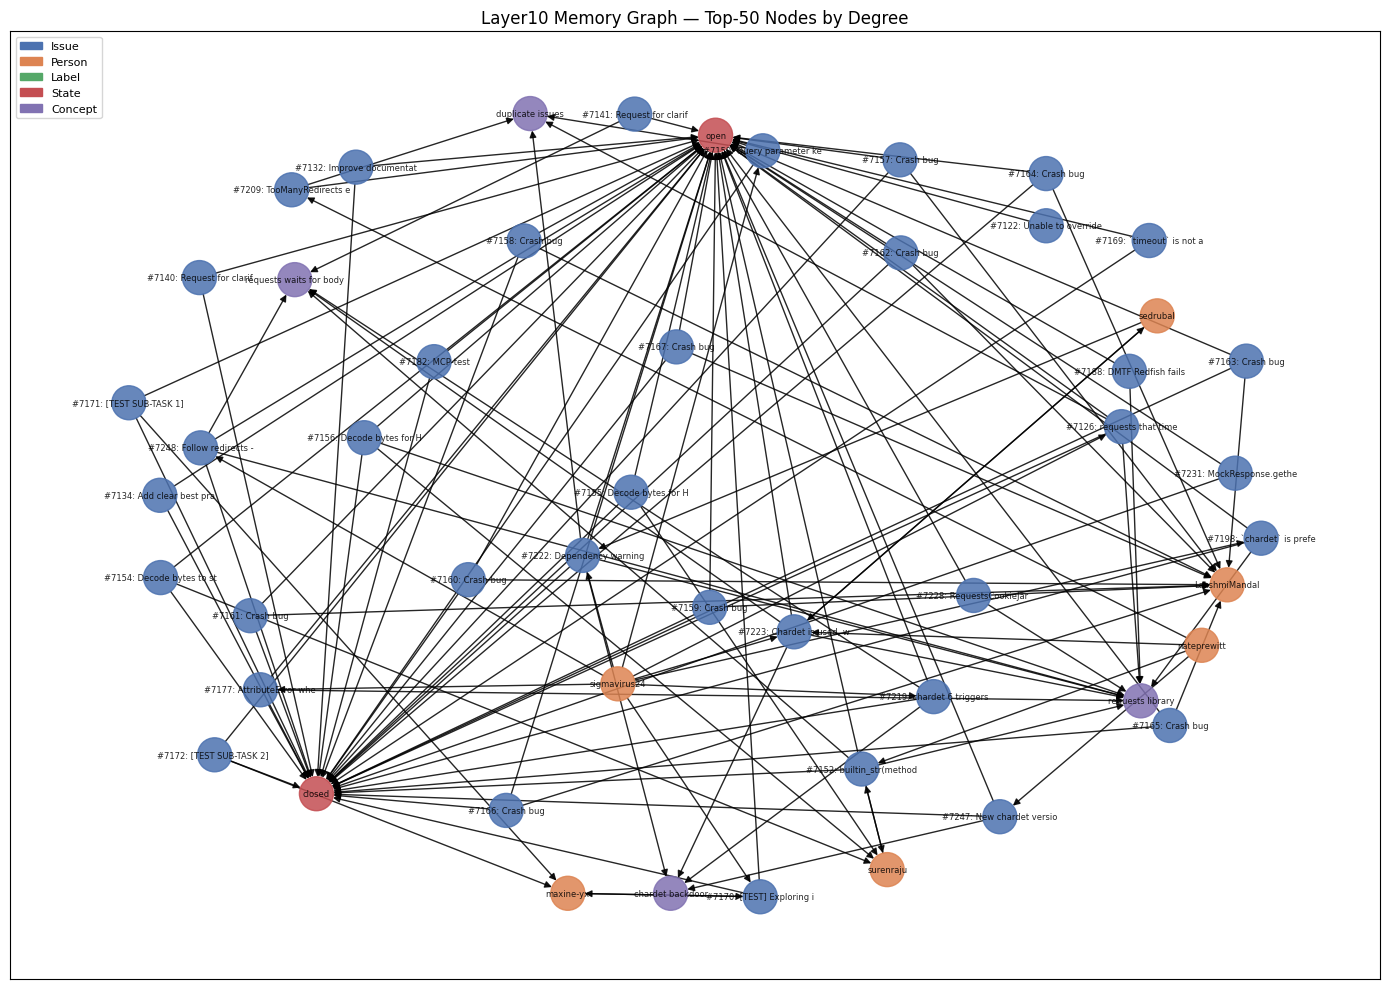

Saved memory_graph_overview.png


In [15]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

G = nx.DiGraph()

NODE_COLORS = {"Issue": "#4C72B0", "Person": "#DD8452",
               "Label": "#55A868", "State": "#C44E52", "Concept": "#8172B2"}

for eid, e in entities.items():
    if e.get("merged_into"): continue
    G.add_node(eid, label=e["canonical_name"][:25], ntype=e["entity_type"])

for c in claims.values():
    if c["subject"] in G and c["object"] in G:
        G.add_edge(c["subject"], c["object"], label=c["relation"])

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# top50 highest degree nodes for readability
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:50]
subG = G.subgraph([n for n, _ in top_nodes])

colors = [NODE_COLORS.get(subG.nodes[n].get("ntype","Concept"), "#aaaaaa") for n in subG.nodes]
labels = {n: subG.nodes[n]["label"] for n in subG.nodes}

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subG, k=1.5, seed=42)
nx.draw_networkx(subG, pos, labels=labels, node_color=colors,
                 node_size=600, font_size=6, arrows=True, alpha=0.85)
patches = [mpatches.Patch(color=v, label=k) for k, v in NODE_COLORS.items()]
plt.legend(handles=patches, loc="upper left", fontsize=8)
plt.title("Layer10 Memory Graph — Top-50 Nodes by Degree", fontsize=12)
plt.tight_layout()
plt.savefig("memory_graph_overview.png", dpi=120)
plt.show()
print("Saved memory_graph_overview.png")


### Streamlit app
To use the UI run the full notebook and then this will launch the interactive UI. Link to it is displayed in next cell below click that and then can see everything.

In [29]:
%%writefile app.py
import streamlit as st
import json, networkx as nx, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

with open("memory_graph.json") as f:
    mem = json.load(f)

entities  = mem["entities"]
claims    = mem["claims"]
evidences = mem["evidences"]
artifacts = mem["artifacts"]

NODE_COLORS = {
    "Issue"  : "#FF6B6B",
    "Person" : "#FFD93D",
    "Label"  : "#6BCB77",
    "State"  : "#4D96FF",
    "Concept": "#FF922B",
}

PINK = "#F472B6"

st.set_page_config(page_title="Layer10 - Memory Graph", layout="wide")

st.markdown(f"""
<style>
@import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;600&display=swap');

* {{ font-family: 'IBM Plex Sans', sans-serif; }}
code, .mono {{ font-family: 'IBM Plex Mono', monospace !important; }}

.stApp {{ background-color: #0d0d0d; color: #e8e8e8; }}

section[data-testid="stSidebar"] {{ background: #111; }}

.stTabs [data-baseweb="tab-list"] {{ border-bottom: 1px solid #2a2a2a; gap: 0px; }}
.stTabs [data-baseweb="tab"] {{
    background: transparent;
    color: #555;
    font-family: 'IBM Plex Mono', monospace;
    font-size: 12px;
    letter-spacing: 0.1em;
    text-transform: uppercase;
    padding: 10px 24px;
    border-radius: 0;
    border-bottom: 2px solid transparent;
}}
.stTabs [aria-selected="true"] {{
    color: {PINK} !important;
    border-bottom: 2px solid {PINK} !important;
    background: transparent !important;
}}

.stExpander {{
    background: #161616 !important;
    border: 1px solid #2a2a2a !important;
    border-radius: 4px !important;
    margin-bottom: 6px;
}}
.stExpander:hover {{ border-color: {PINK} !important; }}

.stSelectbox > div > div,
.stMultiSelect > div > div {{
    background: #161616 !important;
    border-color: #2a2a2a !important;
    color: #e8e8e8 !important;
}}

div[data-testid="stCaption"] {{
    color: #555;
    font-family: 'IBM Plex Mono', monospace;
    font-size: 11px;
}}

.metric-box {{
    background: #161616;
    border: 1px solid #2a2a2a;
    border-top: 2px solid {PINK};
    border-radius: 4px;
    padding: 16px 20px;
    text-align: center;
}}
.metric-number {{
    font-family: 'IBM Plex Mono', monospace;
    font-size: 28px;
    font-weight: 600;
    color: {PINK};
}}
.metric-label {{
    font-size: 11px;
    letter-spacing: 0.1em;
    text-transform: uppercase;
    color: #555;
    margin-top: 4px;
}}

.legend-dot {{
    display: inline-block;
    width: 10px; height: 10px;
    border-radius: 50%;
    margin-right: 6px;
}}

h1 {{ color: {PINK} !important; }}
</style>
""", unsafe_allow_html=True)

st.markdown("# MEMORY GRAPH")
st.markdown(
    f"<span style='font-family:IBM Plex Mono;font-size:12px;color:#444;'>"
    f"corpus: {mem['meta']['corpus']} &nbsp;|&nbsp; "
    f"schema: {mem['meta']['schema_version']} &nbsp;|&nbsp; "
    f"exported: {mem['meta']['exported_at'][:10]}</span>",
    unsafe_allow_html=True)

st.markdown(f"<hr style='border-color:{PINK}33;margin:12px 0 20px 0'>", unsafe_allow_html=True)

c1, c2, c3, c4 = st.columns(4)
counts = mem["meta"]["counts"]
for col, label, val in zip(
    [c1, c2, c3, c4],
    ["ARTIFACTS", "ENTITIES", "CLAIMS", "EVIDENCE"],
    [counts["artifacts"], counts["entities"], counts["claims"], counts["evidences"]]
):
    with col:
        st.markdown(f"""<div class="metric-box">
            <div class="metric-number">{val}</div>
            <div class="metric-label">{label}</div>
        </div>""", unsafe_allow_html=True)

st.markdown("<br>", unsafe_allow_html=True)

legend_html = " &nbsp; ".join(
    f'<span class="legend-dot" style="background:{col}"></span>'
    f'<span style="font-size:12px;color:#666;font-family:IBM Plex Mono">{name}</span>'
    for name, col in NODE_COLORS.items()
)
st.markdown(legend_html, unsafe_allow_html=True)
st.markdown("<br>", unsafe_allow_html=True)

tab1, tab2 = st.tabs(["BROWSE BY ENTITY", "BROWSE BY CONFIDENCE"])

with tab1:
    col1, col2 = st.columns([1, 3], gap="large")

    with col1:
        st.markdown(f"<p style='font-size:11px;letter-spacing:.1em;color:{PINK};text-transform:uppercase'>Select entity</p>",
                    unsafe_allow_html=True)
        entity_names = sorted(
            f"{e['canonical_name']} [{e['entity_type']}]"
            for e in entities.values()
            if not e.get("merged_into")
        )
        chosen = st.selectbox("", entity_names, label_visibility="collapsed")
        show_history = st.checkbox("Show historical claims", value=False)
        entity_types = list(NODE_COLORS.keys())
        chosen_types = st.multiselect("Filter by entity type", entity_types, default=entity_types)

    chosen_name = chosen.split(" [")[0]
    chosen_type = chosen.split("[")[1].replace("]", "")
    eid = next(eid for eid, e in entities.items()
               if e["canonical_name"] == chosen_name
               and e["entity_type"] == chosen_type
               and not e.get("merged_into"))
    entity = entities[eid]

    with col2:
        etype_color = NODE_COLORS.get(entity["entity_type"], "#aaa")
        st.markdown(
            f"<span style='font-family:IBM Plex Mono;font-size:11px;"
            f"background:{etype_color}22;color:{etype_color};"
            f"padding:3px 10px;border-radius:3px;border:1px solid {etype_color}55'>"
            f"{entity['entity_type']}</span>"
            f"<span style='font-size:20px;font-weight:600;margin-left:10px;color:#e8e8e8'>"
            f"{entity['canonical_name']}</span>",
            unsafe_allow_html=True)

        if entity.get("aliases") and len(entity["aliases"]) > 1:
            st.markdown(
                f"<p style='color:#444;font-size:12px;font-family:IBM Plex Mono;margin-top:6px'>"
                f"aliases: {', '.join(entity['aliases'])}</p>",
                unsafe_allow_html=True)

        # duplicate handling
        if entity["entity_type"] == "Issue":
            try:
                issue_num = chosen_name.split(":")[0].replace("#", "").strip()
                art_id = f"issue_{issue_num}_body"
                if art_id in artifacts:
                    art = artifacts[art_id]
                    if art["is_duplicate"]:
                        st.markdown(
                            f"<div style='background:#FF6B6B18;border:1px solid #FF6B6B44;"
                            f"border-radius:4px;padding:8px 12px;margin:8px 0 12px 0;"
                            f"font-family:IBM Plex Mono;font-size:12px'>"
                            f" * <span style='color:#FF6B6B'>DUPLICATE ARTIFACT</span>"
                            f" — identical content to "
                            f"<span style='color:#FFD93D'>{art['duplicate_of']}</span>"
                            f" · no claims were extracted from this artifact</div>",
                            unsafe_allow_html=True)
                    else:
                        dupes = [a["artifact_id"] for a in artifacts.values()
                                 if a.get("duplicate_of") == art_id]
                        if dupes:
                            st.markdown(
                                f"<div style='background:#6BCB7718;border:1px solid #6BCB7744;"
                                f"border-radius:4px;padding:8px 12px;margin:8px 0 12px 0;"
                                f"font-family:IBM Plex Mono;font-size:12px'>"
                                f"✓ <span style='color:#6BCB77'>CANONICAL ARTIFACT</span>"
                                f" — {len(dupes)} duplicate(s) point here: "
                                f"<span style='color:#666'>"
                                f"{', '.join(dupes[:3])}{'...' if len(dupes) > 3 else ''}"
                                f"</span></div>",
                                unsafe_allow_html=True)
            except Exception:
                pass

        related = [c for c in claims.values()
                   if (c["subject"] == eid or c["object"] == eid)
                   and entities[c["subject"]]["entity_type"] in chosen_types
                   and entities[c["object"]]["entity_type"] in chosen_types
                   and (show_history or c["valid_to"] is None)]

        st.markdown(
            f"<p style='color:#444;font-size:12px;font-family:IBM Plex Mono;margin-bottom:12px'>"
            f"{len(related)} claims found</p>",
            unsafe_allow_html=True)

        for claim in related:
            subj = entities[claim["subject"]]["canonical_name"]
            obj  = entities[claim["object"]]["canonical_name"]
            is_hist = bool(claim["valid_to"])
            tag = "HISTORICAL" if is_hist else "CURRENT"
            tag_color = "#4D96FF" if is_hist else "#6BCB77"
            label = (f"[{tag}]  {claim['confidence']:.2f}  ·  "
                     f"{subj[:30]} → {claim['relation']} → {obj[:30]}")
            with st.expander(label):
                cols = st.columns(3)
                cols[0].markdown(
                    f"<span style='color:{PINK};font-size:10px;letter-spacing:.05em'>VALID FROM</span><br>"
                    f"<span style='font-family:IBM Plex Mono;color:#ccc'>{claim['valid_from'][:10]}</span>",
                    unsafe_allow_html=True)
                if claim["valid_to"]:
                    cols[1].markdown(
                        f"<span style='color:{PINK};font-size:10px;letter-spacing:.05em'>VALID TO</span><br>"
                        f"<span style='font-family:IBM Plex Mono;color:#ccc'>{claim['valid_to'][:10]}</span>",
                        unsafe_allow_html=True)
                cols[2].markdown(
                    f"<span style='color:{PINK};font-size:10px;letter-spacing:.05em'>EXTRACTION</span><br>"
                    f"<span style='font-family:IBM Plex Mono;font-size:11px;color:#ccc'>{claim['extraction_version']}</span>",
                    unsafe_allow_html=True)
                st.markdown(f"<hr style='border-color:#222;margin:10px 0'>", unsafe_allow_html=True)
                for ev_id in claim["evidence_ids"]:
                    ev = evidences[ev_id]
                    st.markdown(
                        f"<div style='background:#111;border-left:3px solid {PINK};"
                        f"padding:10px 14px;border-radius:0 4px 4px 0;margin-bottom:8px;"
                        f"font-size:13px;color:#bbb'>{ev['excerpt'][:300]}</div>",
                        unsafe_allow_html=True)
                    st.markdown(
                        f"<a href='{ev['url']}' target='_blank' style='font-family:IBM Plex Mono;"
                        f"font-size:11px;color:{PINK};text-decoration:underline'>"
                        f"↗ {ev['artifact_id']} · {ev['timestamp'][:10]}</a>",
                        unsafe_allow_html=True)

        st.markdown(
            f"<br><p style='font-size:11px;letter-spacing:.1em;color:{PINK};text-transform:uppercase'>Entity graph</p>",
            unsafe_allow_html=True)

        G = nx.DiGraph()
        for c in related:
            for nid in (c["subject"], c["object"]):
                e = entities[nid]
                G.add_node(nid, label=e["canonical_name"][:22], ntype=e["entity_type"])
            G.add_edge(c["subject"], c["object"], label=c["relation"])

        if G.number_of_nodes():
            pos = nx.spring_layout(G, seed=42, k=2)
            nc  = [NODE_COLORS.get(G.nodes[n].get("ntype", ""), "#aaa") for n in G.nodes]
            nl  = {n: G.nodes[n]["label"] for n in G.nodes}
            el  = {(u, v): d["label"].replace("_", " ") for u, v, d in G.edges(data=True)}
            fig, ax = plt.subplots(figsize=(8, 5))
            fig.patch.set_facecolor("#0d0d0d")
            ax.set_facecolor("#0d0d0d")
            nx.draw_networkx_nodes(G, pos, ax=ax, node_color=nc, node_size=800, alpha=0.95)
            nx.draw_networkx_edges(G, pos, ax=ax, edge_color=PINK, arrows=True,
                                   arrowsize=15, width=1.2, connectionstyle="arc3,rad=0.1",
                                   alpha=0.5)
            nx.draw_networkx_labels(G, pos, nl, ax=ax, font_size=7,
                                    font_color="white", font_weight="bold")
            nx.draw_networkx_edge_labels(G, pos, el, ax=ax, font_size=6,
                                          font_color=PINK, bbox=dict(alpha=0))
            ax.axis("off")
            st.pyplot(fig)
        else:
            st.markdown("<p style='color:#333;font-size:13px'>No graph edges for current filters.</p>",
                        unsafe_allow_html=True)

with tab2:
    st.markdown(
        f"<p style='font-size:11px;letter-spacing:.1em;color:{PINK};text-transform:uppercase'>"
        f"All claims — filter by confidence</p>",
        unsafe_allow_html=True)

    max_conf = st.slider("Show claims with confidence ≤", 0.0, 1.0, 1.0, step=0.05, key="max_conf")

    filtered = [c for c in claims.values()
                if c["confidence"] <= max_conf]
    filtered.sort(key=lambda c: c["confidence"])

    st.markdown(
        f"<p style='color:#444;font-size:12px;font-family:IBM Plex Mono'>"
        f"{len(filtered)} claims with confidence ≤ {max_conf}</p>",
        unsafe_allow_html=True)

    for claim in filtered:
        subj = entities[claim["subject"]]["canonical_name"]
        obj  = entities[claim["object"]]["canonical_name"]
        conf = claim["confidence"]
        conf_color = "#6BCB77" if conf >= 0.85 else "#FFD93D" if conf >= 0.7 else "#FF6B6B"
        label = f"{conf:.2f}  ·  {subj[:35]} → {claim['relation']} → {obj[:35]}"
        with st.expander(label):
            st.markdown(
                f"<span style='font-family:IBM Plex Mono;font-size:11px;"
                f"background:{conf_color}22;color:{conf_color};"
                f"padding:2px 8px;border-radius:3px;border:1px solid {conf_color}44'>"
                f"confidence: {conf:.2f}</span>",
                unsafe_allow_html=True)
            st.markdown("<br>", unsafe_allow_html=True)
            st.markdown(
                f"<span style='color:{PINK};font-size:10px'>VALID FROM</span> "
                f"<code>{claim['valid_from'][:10]}</code>",
                unsafe_allow_html=True)
            if claim["valid_to"]:
                st.markdown(
                    f"<span style='color:{PINK};font-size:10px'>VALID TO</span> "
                    f"<code>{claim['valid_to'][:10]}</code>",
                    unsafe_allow_html=True)
            st.markdown(
                f"<span style='color:{PINK};font-size:10px'>EXTRACTION</span> "
                f"<code>{claim['extraction_version']}</code>",
                unsafe_allow_html=True)
            st.markdown(f"<hr style='border-color:#222;margin:10px 0'>", unsafe_allow_html=True)
            for ev_id in claim["evidence_ids"]:
                ev = evidences[ev_id]
                st.markdown(
                    f"<div style='background:#111;border-left:3px solid {PINK};"
                    f"padding:10px 14px;border-radius:0 4px 4px 0;margin-bottom:8px;"
                    f"font-size:13px;color:#bbb'>{ev['excerpt'][:300]}</div>",
                    unsafe_allow_html=True)
                st.markdown(
                    f"<a href='{ev['url']}' target='_blank' style='font-family:IBM Plex Mono;"
                    f"font-size:11px;color:{PINK};text-decoration:underline'>"
                    f"↗ {ev['artifact_id']} · {ev['timestamp'][:10]}</a>",
                    unsafe_allow_html=True)

Overwriting app.py


URL displayed here, click on the first link then when it opens click on "visit site"


but before login to ngrok and from "https://dashboard.ngrok.com/get-started/your-authtoken" get your ngrok token and paste it here

In [31]:
import subprocess, time
from pyngrok import ngrok

ngrok.set_auth_token("YOURKEYHERE")

# Kill any outstanding ngrok tunnels to avoid exceeding endpoint limits
ngrok.kill()

subprocess.Popen(["streamlit", "run", "app.py",
                  "--server.port", "8501",
                  "--server.headless", "true"])

time.sleep(4)
public_url = ngrok.connect(8501)
print("URL to the UI:", public_url)

URL to the UI: NgrokTunnel: "https://da93-104-199-168-18.ngrok-free.app" -> "http://localhost:8501"


# Proofs for WriteUp

# IGNORE from below,

**Below is just code snippets to show proof in my write up**


Small test and proof that it is working correctly, on the UI u can see the following numbers seeming to be the same but this is proof that they are being correctly flagged as duplicates by the system.

In [18]:
# check if these crash bug issues have identical bodies
crash_issues = [i for i in clean_issues if i["title"].lower() == "crash bug"]
for i in crash_issues:
    print(f"#{i['issue_id']} | body: {i['body'][:150]}")
    print()

#7167 | body: App crashes on timeout

#7166 | body: App crashes on timeout

#7165 | body: App crashes on timeout

#7164 | body: App crashes on timeout

#7163 | body: App crashes on timeout

#7162 | body: App crashes on timeout

#7161 | body: App crashes on timeout

#7160 | body: App crashes on timeout

#7159 | body: App crashes on timeout

#7158 | body: App crashes on timeout

#7157 | body: App crashes on timeout



In [19]:
# check if they got flagged as duplicates
for i in crash_issues:
    art_id = f"issue_{i['issue_id']}_body"
    art = artifact_store[art_id]
    print(f"#{i['issue_id']} | is_duplicate: {art['is_duplicate']} | duplicate_of: {art['duplicate_of']}")

#7167 | is_duplicate: False | duplicate_of: None
#7166 | is_duplicate: True | duplicate_of: issue_7167_body
#7165 | is_duplicate: True | duplicate_of: issue_7167_body
#7164 | is_duplicate: True | duplicate_of: issue_7167_body
#7163 | is_duplicate: True | duplicate_of: issue_7167_body
#7162 | is_duplicate: True | duplicate_of: issue_7167_body
#7161 | is_duplicate: True | duplicate_of: issue_7167_body
#7160 | is_duplicate: True | duplicate_of: issue_7167_body
#7159 | is_duplicate: True | duplicate_of: issue_7167_body
#7158 | is_duplicate: True | duplicate_of: issue_7167_body
#7157 | is_duplicate: True | duplicate_of: issue_7167_body


In [20]:
matches = [(eid, e) for eid, e in entities.items()
           if e["canonical_name"] == "davidism"]
for eid, e in matches:
    print(e["entity_type"], "→", e["canonical_name"])

Person → davidism
Concept → davidism


In [21]:
for eid, e in matches:
    related = [c for c in claims.values()
               if c["subject"] == eid or c["object"] == eid]
    print(f"\n{e['entity_type']} → {e['canonical_name']}")
    for c in related[:3]:
        print(f"  {c['relation']}")


Person → davidism
  COMMENTED_ON

Concept → davidism
  MENTIONS_USER
